# Dropout — Improving Neural Networks by Preventing Co-adaptation of Feature Detectors

Paper: [arXiv:1207.0580](https://arxiv.org/abs/1207.0580)

This notebook builds a small MLP in PyTorch and trains it with and without Dropout on Fashion-MNIST, then compares train vs test loss curves to show how dropout closes the overfitting gap.

## 1. Setup & Imports

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load Fashion-MNIST

In [2]:
def get_fashion_mnist_loaders(batch_size=128, num_workers=2):
    transform = transforms.ToTensor()

    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )
    return train_loader, test_loader

train_loader, test_loader = get_fashion_mnist_loaders(batch_size=128)
print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 65.5k/26.4M [00:00<01:09, 382kB/s]

  1%|          | 229k/26.4M [00:00<00:36, 710kB/s] 

  3%|▎         | 918k/26.4M [00:00<00:11, 2.19MB/s]

 14%|█▍        | 3.67M/26.4M [00:00<00:03, 7.54MB/s]

...

 83%|████████▎ | 3.67M/4.42M [00:00<00:00, 7.48MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 6.26MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]

Train batches: 469, Test batches: 79


## 3. Model Definition

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(256, 128), num_classes=10, dropout_p=0.0):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Verify model shape
dummy = torch.zeros(4, 1, 28, 28).to(device)
model_dummy = MLP(dropout_p=0.5).to(device)
print(f'Dummy output shape: {model_dummy(dummy).shape}')

Dummy output shape: torch.Size([4, 10])


## 4. Train/Eval Helpers

In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, device, epochs=25, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Epoch {epoch:02d}/{epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}')

    return history

## 5. Train Two Models (with and without Dropout)

In [5]:
EPOCHS = 25
LR = 1e-3

model_no_dropout = MLP(dropout_p=0.0).to(device)
model_dropout = MLP(dropout_p=0.5).to(device)

print('\n=== Training model WITHOUT dropout (p=0.0) ===')
history_no_dropout = train_model(model_no_dropout, train_loader, test_loader, device, epochs=EPOCHS, lr=LR)

print('\n=== Training model WITH dropout (p=0.5) ===')
history_dropout = train_model(model_dropout, train_loader, test_loader, device, epochs=EPOCHS, lr=LR)


=== Training model WITHOUT dropout (p=0.0) ===


Epoch 01/25 | train_loss: 0.5717 | train_acc: 0.8028 | test_loss: 0.4588 | test_acc: 0.8389


Epoch 02/25 | train_loss: 0.3869 | train_acc: 0.8616 | test_loss: 0.3982 | test_acc: 0.8543


Epoch 03/25 | train_loss: 0.3438 | train_acc: 0.8741 | test_loss: 0.3721 | test_acc: 0.8669


Epoch 04/25 | train_loss: 0.3202 | train_acc: 0.8821 | test_loss: 0.3600 | test_acc: 0.8677


...

Epoch 21/25 | train_loss: 0.3206 | train_acc: 0.8819 | test_loss: 0.3262 | test_acc: 0.8828


Epoch 22/25 | train_loss: 0.3170 | train_acc: 0.8848 | test_loss: 0.3327 | test_acc: 0.8780


Epoch 23/25 | train_loss: 0.3135 | train_acc: 0.8860 | test_loss: 0.3243 | test_acc: 0.8847


Epoch 24/25 | train_loss: 0.3101 | train_acc: 0.8855 | test_loss: 0.3273 | test_acc: 0.8835


Epoch 25/25 | train_loss: 0.3109 | train_acc: 0.8860 | test_loss: 0.3235 | test_acc: 0.8822


## 6. Plot Train vs Test Loss Curves

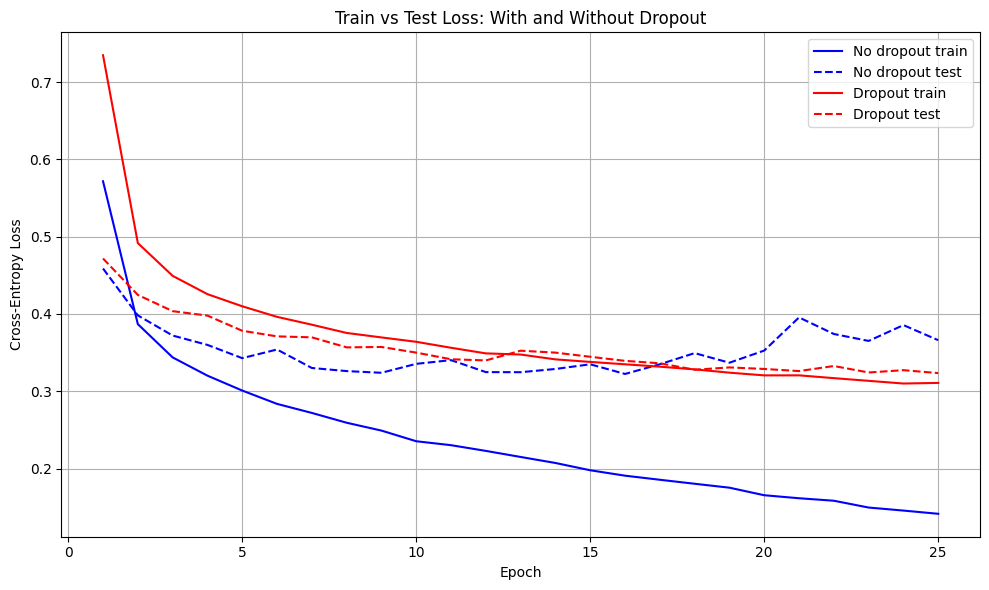

In [6]:
def plot_losses(hist_no_dropout, hist_dropout):
    epochs = range(1, len(hist_no_dropout['train_loss']) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, hist_no_dropout['train_loss'], 'b-', label='No dropout train')
    plt.plot(epochs, hist_no_dropout['test_loss'], 'b--', label='No dropout test')
    plt.plot(epochs, hist_dropout['train_loss'], 'r-', label='Dropout train')
    plt.plot(epochs, hist_dropout['test_loss'], 'r--', label='Dropout test')

    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Train vs Test Loss: With and Without Dropout')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_losses(history_no_dropout, history_dropout)

## 7. Final Accuracy Comparison

In [7]:
criterion = nn.CrossEntropyLoss()

final_no_dropout_train_loss, final_no_dropout_train_acc = evaluate(model_no_dropout, train_loader, criterion, device)
final_no_dropout_test_loss, final_no_dropout_test_acc = evaluate(model_no_dropout, test_loader, criterion, device)

final_dropout_train_loss, final_dropout_train_acc = evaluate(model_dropout, train_loader, criterion, device)
final_dropout_test_loss, final_dropout_test_acc = evaluate(model_dropout, test_loader, criterion, device)

print('\n=== Final Results ===')
print(f'No dropout  | train acc: {final_no_dropout_train_acc:.4f} | test acc: {final_no_dropout_test_acc:.4f} | gap: {final_no_dropout_train_acc - final_no_dropout_test_acc:.4f}')
print(f'Dropout     | train acc: {final_dropout_train_acc:.4f} | test acc: {final_dropout_test_acc:.4f} | gap: {final_dropout_train_acc - final_dropout_test_acc:.4f}')


=== Final Results ===
No dropout  | train acc: 0.9504 | test acc: 0.8917 | gap: 0.0587
Dropout     | train acc: 0.9085 | test acc: 0.8822 | gap: 0.0263


## 8. Optional: Visualize a Dropout Mask

In [8]:
# Grab one batch and compare train-mode (dropout active) vs eval-mode (dropout off) activations
sample_images, _ = next(iter(test_loader))
sample_images = sample_images[:1].to(device)

model_dropout.train()
with torch.no_grad():
    x = sample_images.view(sample_images.size(0), -1)
    x1_train = model_dropout.relu(model_dropout.fc1(x))
    x1_train = model_dropout.dropout(x1_train)

model_dropout.eval()
with torch.no_grad():
    x = sample_images.view(sample_images.size(0), -1)
    x1_eval = model_dropout.relu(model_dropout.fc1(x))
    x1_eval = model_dropout.dropout(x1_eval)

# In eval mode, PyTorch dropout is identity; in train mode, some units are zeroed.
dropped = (x1_train == 0).float().cpu().numpy().flatten()
print(f'Hidden units after first layer: {len(dropped)}')
print(f'Units dropped in this train-mode forward pass: {int(dropped.sum())} ({100*dropped.mean():.1f}%)')

Hidden units after first layer: 256
Units dropped in this train-mode forward pass: 232 (90.6%)


In [ ]:
# Save the executed notebook with outputs back to Kaggle output for validation
import shutil
shutil.copy('__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
print('Executed notebook saved to /kaggle/working/executed_solution.ipynb')